In [1]:
import pandas as pd

# --- 1) Read each week's CSV ---
df_wk0 = pd.read_csv('week0.csv')
df_wk2 = pd.read_csv('week2.csv')
df_wk4 = pd.read_csv('week4.csv')

# --- 2) Add pulled_date columns ---
df_wk0["pulled_date"] = "2025-02-12"
df_wk2["pulled_date"] = "2025-03-01"
df_wk4["pulled_date"] = "2025-03-16"

# --- 3) Convert "Video Posted" and "pulled_date" to datetime ---
#     And remove any time zone info if present
df_wk0["Video Posted"] = (
    pd.to_datetime(df_wk0["Video Posted"], errors="coerce", utc=True)
    .dt.tz_convert(None)
)
df_wk0["pulled_date"] = pd.to_datetime(df_wk0["pulled_date"], utc=True).dt.tz_convert(None)

df_wk2["Video Posted"] = (
    pd.to_datetime(df_wk2["Video Posted"], errors="coerce", utc=True)
    .dt.tz_convert(None)
)
df_wk2["pulled_date"] = pd.to_datetime(df_wk2["pulled_date"], utc=True).dt.tz_convert(None)

df_wk4["Video Posted"] = (
    pd.to_datetime(df_wk4["Video Posted"], errors="coerce", utc=True)
    .dt.tz_convert(None)
)
df_wk4["pulled_date"] = pd.to_datetime(df_wk4["pulled_date"], utc=True).dt.tz_convert(None)

# --- 4) Calculate days since posting ---
df_wk0["days_since_posting"] = (df_wk0["pulled_date"] - df_wk0["Video Posted"]).dt.days
df_wk2["days_since_posting"] = (df_wk2["pulled_date"] - df_wk2["Video Posted"]).dt.days
df_wk4["days_since_posting"] = (df_wk4["pulled_date"] - df_wk4["Video Posted"]).dt.days

# (Optional) Concatenate all weeks
df_all = pd.concat([df_wk0, df_wk2, df_wk4], ignore_index=True)
print(df_all.columns)
print(df_all.head(50))

Index(['Channel Name', 'Subscriber Count', 'Total Videos', 'Total Views',
       'View Count', 'Like Count', 'Comment Count', 'Video Posted',
       'Video Link', 'pulled_date', 'days_since_posting', 'Unnamed: 9'],
      dtype='object')
             Channel Name  Subscriber Count  Total Videos  Total Views  \
0   The Infographics Show          14800000          5354   6251451295   
1   The Infographics Show          14800000          5354   6251451295   
2   The Infographics Show          14800000          5354   6251451295   
3   The Infographics Show          14800000          5354   6251451295   
4   The Infographics Show          14800000          5354   6251451295   
5   The Infographics Show          14800000          5354   6251451295   
6   The Infographics Show          14800000          5354   6251451295   
7   The Infographics Show          14800000          5354   6251451295   
8   The Infographics Show          14800000          5354   6251451295   
9   The Infographics Sh

In [4]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

X = df_all.drop(columns=["Channel Name"])   # your features
y = df_all["Channel Name"]                  # your categorical target

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Now each "Channel Name" class is oversampled to match the frequency of the majority class
df_resampled = pd.concat([X_resampled, y_resampled], axis=1)


/Users/justinhuang/.local/lib/python3.12/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/justinhuang/.local/lib/python3.12/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [5]:
import pandas as pd

# Use your existing DataFrames:
# df_wk0, df_wk2, df_wk4

# Merge df_wk0 into df_wk4 on Channel Name
# The suffixes parameter will keep columns separate: 
#   e.g. Subscriber Count_wk0 vs. Subscriber Count_wk4 (if any).
df_merged = pd.merge(
    df_wk4,
    df_wk0,
    on="Channel Name",
    how="left",
    suffixes=("_wk4", "_wk0")
)

# Now 'df_merged' has columns from wk4 + wk0.
print(df_merged.columns)


Index(['Channel Name', 'Subscriber Count_wk4', 'Total Videos_wk4',
       'Total Views_wk4', 'View Count_wk4', 'Like Count_wk4',
       'Comment Count_wk4', 'Video Posted_wk4', 'Video Link_wk4', 'Unnamed: 9',
       'pulled_date_wk4', 'days_since_posting_wk4', 'Subscriber Count_wk0',
       'Total Videos_wk0', 'Total Views_wk0', 'View Count_wk0',
       'Like Count_wk0', 'Comment Count_wk0', 'Video Posted_wk0',
       'Video Link_wk0', 'pulled_date_wk0', 'days_since_posting_wk0'],
      dtype='object')


In [8]:
import numpy as np

numeric_cols = [
    "Subscriber Count_wk0",
    "Total Videos_wk0",
    "Total Views_wk0",
    "View Count_wk0",
    "Like Count_wk0",
    "Comment Count_wk0"
]

for col in numeric_cols:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")

# Now columns that were strings become floats (with NaN if unparseable).
df_merged["subscribers_per_video_wk0"] = (
    df_merged["Subscriber Count_wk0"] 
    / df_merged["Total Videos_wk0"].replace(0, np.nan)
)
df_merged["views_per_subscriber_wk0"] = (
    df_merged["Total Views_wk0"] 
    / df_merged["Subscriber Count_wk0"].replace(0, np.nan)
)
df_merged["like_ratio_wk0"] = (
    df_merged["Like Count_wk0"] 
    / df_merged["View Count_wk0"].replace(0, np.nan)
)
df_merged["comment_ratio_wk0"] = (
    df_merged["Comment Count_wk0"] 
    / df_merged["View Count_wk0"].replace(0, np.nan)
)
print(df_merged.columns)


Index(['Channel Name', 'Subscriber Count_wk4', 'Total Videos_wk4',
       'Total Views_wk4', 'View Count_wk4', 'Like Count_wk4',
       'Comment Count_wk4', 'Video Posted_wk4', 'Video Link_wk4', 'Unnamed: 9',
       'pulled_date_wk4', 'days_since_posting_wk4', 'Subscriber Count_wk0',
       'Total Videos_wk0', 'Total Views_wk0', 'View Count_wk0',
       'Like Count_wk0', 'Comment Count_wk0', 'Video Posted_wk0',
       'Video Link_wk0', 'pulled_date_wk0', 'days_since_posting_wk0',
       'subscribers_per_video_wk0', 'views_per_subscriber_wk0',
       'like_ratio_wk0', 'comment_ratio_wk0'],
      dtype='object')


In [28]:
df_channel_level = (
    df_merged.groupby("Channel Name", as_index=False)
             .agg({
                 # The target: average views for all that channel's Week 4 videos
                 "View Count_wk4": "mean",
                 "View Count_wk0": "mean",
                 # (Optional) you could store how many videos in wk4 each channel has
                 "Video Link_wk4": "count"    # or whichever column identifies distinct videos
             })
             .rename(columns={
                 "View Count_wk4": "avg_views_wk4",
                 "View Count_wk0": "avg_views_wk0",
                 "Video Link": "wk4_num_videos"
             })
)

# Now df_channel_level has 1 row per channel with:
#   Channel Name, avg_views_wk4, wk4_num_videos


In [30]:
df_channel_features = (
    df_merged.groupby("Channel Name", as_index=False)
             .agg({
                 "Subscriber Count_wk0": "max",
                 "Total Videos_wk0": "max",
                 "Total Views_wk0": "max",
                 "View Count_wk0" : "mean",
                 "subscribers_per_video_wk0": "mean",
                 "views_per_subscriber_wk0": "mean",
                 "like_ratio_wk0": "mean",
                 "comment_ratio_wk0": "mean",
                 # any other columns from wk0 that you want at the channel level
             })
)


In [32]:
df_final = pd.merge(
    df_channel_features, 
    df_channel_level, 
    on="Channel Name", 
    how="inner"
)

# df_final now has:
#    Channel Name, all wk0 aggregated features, plus
#    avg_views_wk4 (the target)


In [34]:
# Create a filtered DataFrame that excludes channels above 5e6 avg views
df_final_filtered = df_final[df_final["avg_views_wk4"] < 5_000_000].copy()

print("Original dataset size:", len(df_final))
print("Filtered dataset size:", len(df_final_filtered))


Original dataset size: 33
Filtered dataset size: 32


Linear Regression: R² = 0.257, RMSE = 391,278.05
Ridge Regression: R² = 0.267, RMSE = 388,632.99


/Users/justinhuang/.local/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.71523e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/justinhuang/.local/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.1686e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/justinhuang/.local/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.31259e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/justinhuang/.local/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.19069e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/justinhuang/.local/lib

Random Forest: R² = 0.404, RMSE = 350,266.85
Gradient Boosting: R² = 0.303, RMSE = 379,028.33

Summary of Cross-Validation Results:
               Model        R2           RMSE
0  Linear Regression  0.256787  391278.048775
1   Ridge Regression  0.266801  388632.993005
2      Random Forest  0.404420  350266.846352
3  Gradient Boosting  0.302594  379028.332830


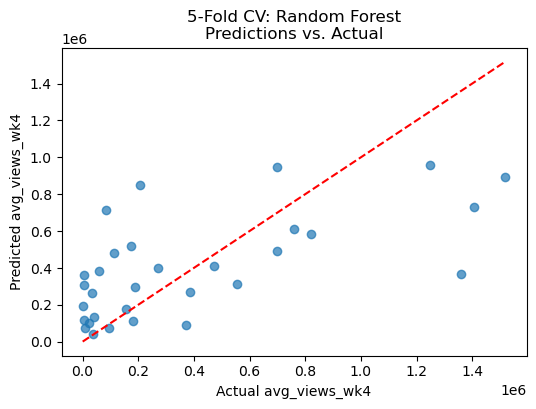

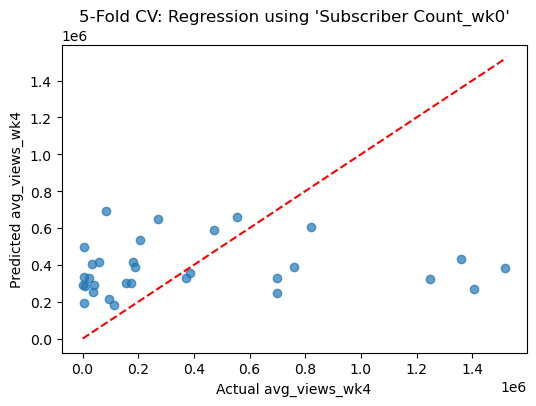

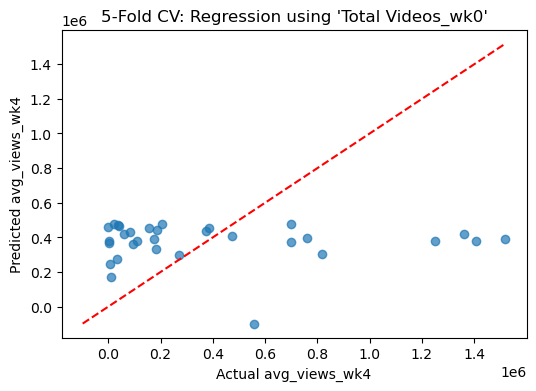

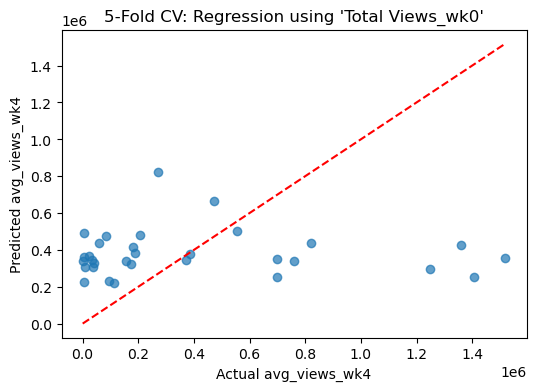

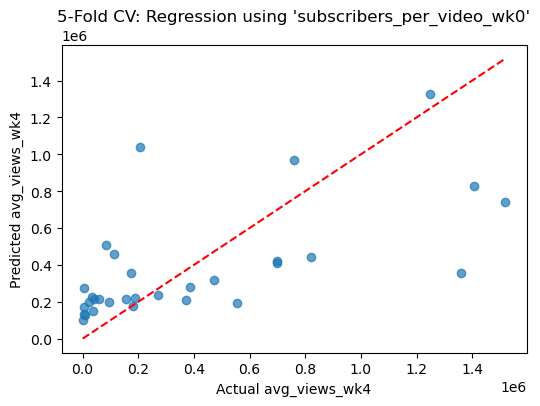

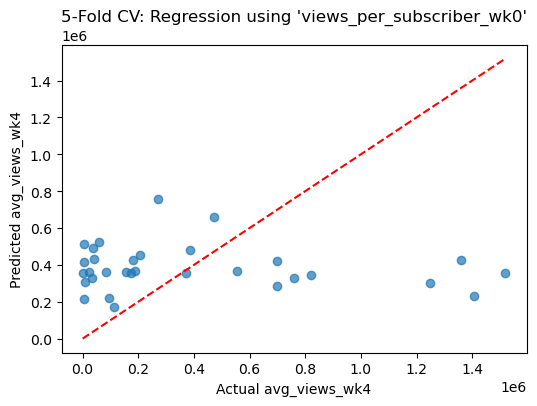

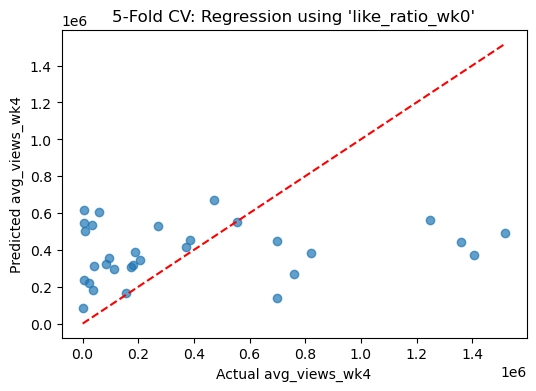

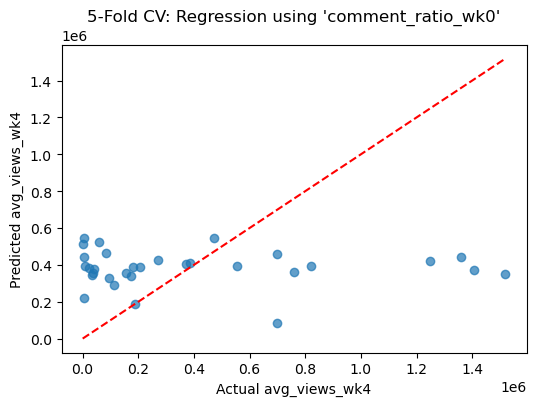

Single Predictor Regression Performance:
                Model        R2           RMSE                    Feature
0   Linear Regression  0.256787  391278.048775                        NaN
1    Ridge Regression  0.266801  388632.993005                        NaN
2       Random Forest  0.404420  350266.846352                        NaN
3   Gradient Boosting  0.302594  379028.332830                        NaN
4                 NaN -0.038690  462564.052049       Subscriber Count_wk0
5                 NaN -0.073832  470323.756299           Total Videos_wk0
6                 NaN -0.094469  474821.754763            Total Views_wk0
7                 NaN  0.402162  350929.987399  subscribers_per_video_wk0
8                 NaN -0.137333  484030.382447   views_per_subscriber_wk0
9                 NaN  0.018443  449662.441010             like_ratio_wk0
10                NaN -0.060272  467344.972159          comment_ratio_wk0


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_squared_error

# -------------------------------
# Prepare the data
# -------------------------------
# Remove channels with avg_views_wk4 below a threshold (e.g., < 1000)
df_final_filtered2 = df_final_filtered[df_final_filtered["avg_views_wk4"] > 1000].copy()
df_final_filtered2 = df_final_filtered[df_final_filtered["avg_views_wk4"] < 2000000].copy()
# Define features and target
feature_cols = [
    "Subscriber Count_wk0",
    "Total Videos_wk0",
    "Total Views_wk0",
    "subscribers_per_video_wk0",
    "views_per_subscriber_wk0",
    "like_ratio_wk0",
    "comment_ratio_wk0",
]
X = df_final_filtered2[feature_cols].fillna(0)
y = df_final_filtered2["avg_views_wk4"]

# Define a 5-fold cross-validation splitter
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------------
# Define and Evaluate Models
# -------------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=15),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=15)
}

results = []

for name, model in models.items():
    # Get cross-validated predictions
    y_pred = cross_val_predict(model, X, y, cv=cv)
    
    # Compute performance metrics
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    
    results.append({"Model": name, "R2": r2, "RMSE": rmse})
    print(f"{name}: R² = {r2:.3f}, RMSE = {rmse:,.2f}")

# Optionally convert the results into a DataFrame for a summary table.
results_df = pd.DataFrame(results)
print("\nSummary of Cross-Validation Results:")
print(results_df)

# -------------------------------
# Plotting for one of the models for illustration
# -------------------------------
# For example, plot predictions vs. actual for the Random Forest model:
model_name = "Random Forest"
rf = models[model_name]
y_pred_rf = cross_val_predict(rf, X, y, cv=cv)

plt.figure(figsize=(6, 4))
plt.scatter(y, y_pred_rf, alpha=0.7)
plt.xlabel("Actual avg_views_wk4")
plt.ylabel("Predicted avg_views_wk4")
plt.title(f"5-Fold CV: {model_name}\nPredictions vs. Actual")
min_val = min(y.min(), y_pred_rf.min())
max_val = max(y.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], '--', color='red')
plt.show()
for feature in feature_cols:
    # Use the single feature as predictor
    X_single = df_final_filtered2[[feature]].fillna(0)
    
    # Define the model and get cross-validated predictions
    linreg = LinearRegression()
    predictions = cross_val_predict(linreg, X_single, y, cv=cv)
    
    # Calculate performance metrics
    r2 = r2_score(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mse)
    
    results.append({
        "Feature": feature,
        "R2": r2,
        "RMSE": rmse
    })
    
    # Plot scatter plot for the current predictor
    plt.figure(figsize=(6, 4))
    plt.scatter(y, predictions, alpha=0.7)
    plt.xlabel("Actual avg_views_wk4")
    plt.ylabel("Predicted avg_views_wk4")
    plt.title(f"5-Fold CV: Regression using '{feature}'")
    # Add a diagonal line representing perfect prediction
    min_val = min(y.min(), predictions.min())
    max_val = max(y.max(), predictions.max())
    plt.plot([min_val, max_val], [min_val, max_val], '--', color='red')
    plt.show()

# Print out summary of results
results_df = pd.DataFrame(results)
print("Single Predictor Regression Performance:")
print(results_df)


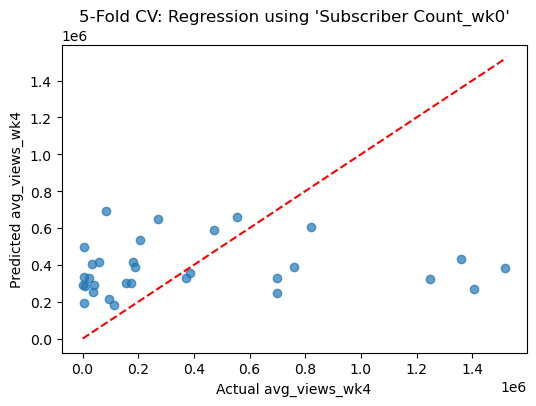

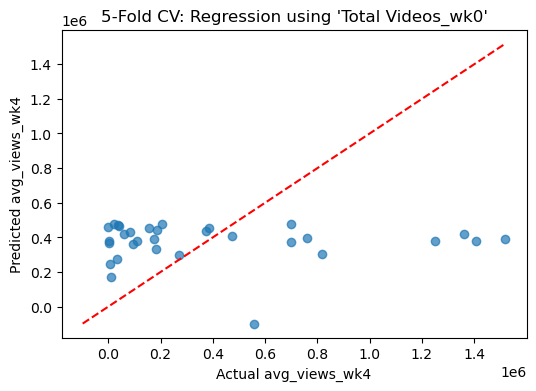

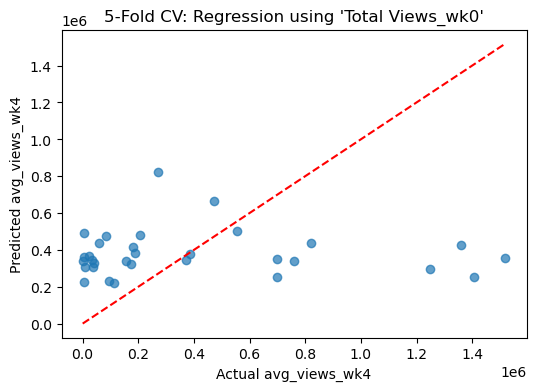

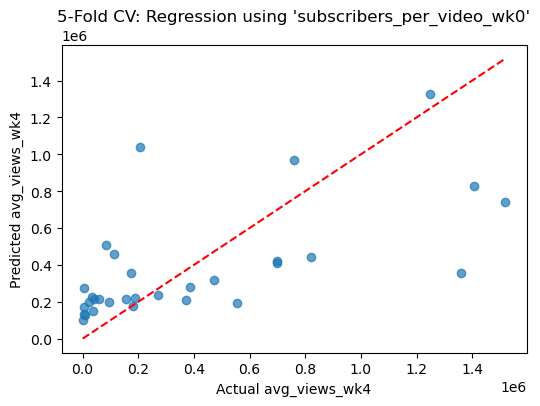

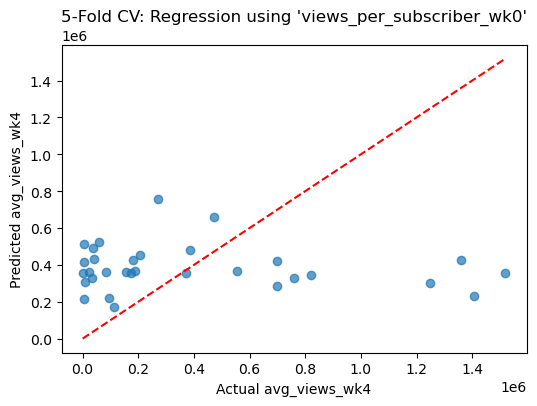

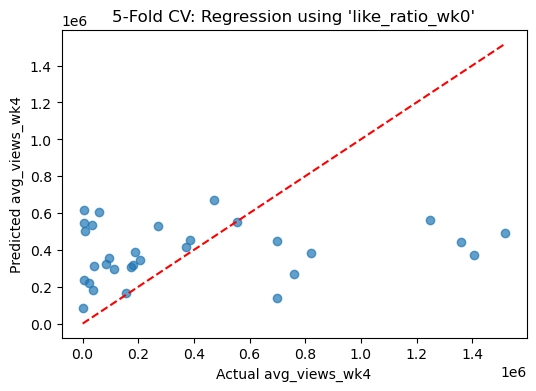

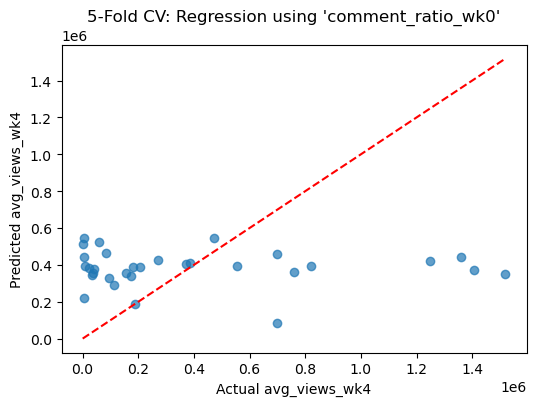

Single Predictor Regression Performance:
                     Feature        R2           RMSE
0       Subscriber Count_wk0 -0.038690  462564.052049
1           Total Videos_wk0 -0.073832  470323.756299
2            Total Views_wk0 -0.094469  474821.754763
3  subscribers_per_video_wk0  0.402162  350929.987399
4   views_per_subscriber_wk0 -0.137333  484030.382447
5             like_ratio_wk0  0.018443  449662.441010
6          comment_ratio_wk0 -0.060272  467344.972159


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_squared_error

# Assuming df_final_filtered2 is already defined and filtered:
# It should contain "avg_views_wk4" (target) and your feature columns.
feature_cols = [
    "Subscriber Count_wk0",
    "Total Videos_wk0",
    "Total Views_wk0",
    "subscribers_per_video_wk0",
    "views_per_subscriber_wk0",
    "like_ratio_wk0",
    "comment_ratio_wk0"
]

# Prepare a container to store performance results
results = []

# We use the same CV splitter for each regression:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y = df_final_filtered2["avg_views_wk4"]

for feature in feature_cols:
    # Use the single feature as predictor
    X_single = df_final_filtered2[[feature]].fillna(0)
    
    # Define the model and get cross-validated predictions
    linreg = LinearRegression()
    predictions = cross_val_predict(linreg, X_single, y, cv=cv)
    
    # Calculate performance metrics
    r2 = r2_score(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mse)
    
    results.append({
        "Feature": feature,
        "R2": r2,
        "RMSE": rmse
    })
    
    # Plot scatter plot for the current predictor
    plt.figure(figsize=(6, 4))
    plt.scatter(y, predictions, alpha=0.7)
    plt.xlabel("Actual avg_views_wk4")
    plt.ylabel("Predicted avg_views_wk4")
    plt.title(f"5-Fold CV: Regression using '{feature}'")
    # Add a diagonal line representing perfect prediction
    min_val = min(y.min(), predictions.min())
    max_val = max(y.max(), predictions.max())
    plt.plot([min_val, max_val], [min_val, max_val], '--', color='red')
    plt.show()

# Print out summary of results
results_df = pd.DataFrame(results)
print("Single Predictor Regression Performance:")
print(results_df)


In [38]:
pip install pymc


Note: you may need to restart the kernel to use updated packages.


Output()

Finished [100%]: Average Loss = 1.1399e+08
/var/folders/y3/y2wq_hvx7kscqsdrpjl8m6h80000gn/T/ipykernel_77765/2193566779.py:75: RuntimeWarning: overflow encountered in exp
  p_samples = 1 / (1 + np.exp(-eta_samples))
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
Intercept -1.421  0.988  -3.147    0.412      0.033    0.023     920.0   
Coeffs[0] -1.066  0.490  -1.936   -0.115      0.016    0.011     990.0   
Coeffs[1]  1.839  0.715   0.522    3.172      0.021    0.015    1132.0   
Coeffs[2]  0.005  0.007  -0.007    0.017      0.000    0.000     978.0   
Coeffs[3] -2.934  0.687  -4.261   -1.747      0.022    0.016     974.0   
Coeffs[4] -1.101  0.670  -2.320    0.159      0.021    0.015    1043.0   
Coeffs[5] -2.631  3.701  -9.323    4.518      0.131    0.093     789.0   
Coeffs[6] -1.439  5.614 -10.601    9.572      0.188    0.133     895.0   

           ess_tail  r_hat  
Intercept     819.0    NaN  
Coeffs[0]    1016.0    NaN  
Coeffs[1]     978.0    NaN  
Coeffs[2]     947.0    NaN  
Coeffs[3]     855.0    NaN  
Coeffs[4]     980.0    NaN  
Coeffs[5]     852.0    NaN  
Coeffs[6]    1011.0    NaN  
             Channel Name  avg_views_wk4  target_binary  predicted_proba

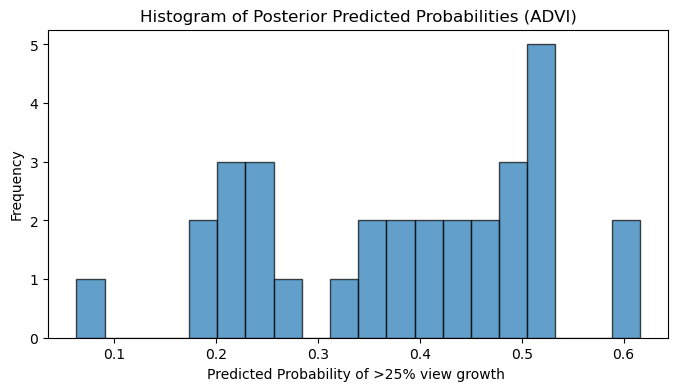

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# ------------------------------
# 1) Data Preparation
# ------------------------------
# Here we work on a DataFrame df_final_filtered2 (or df_bayes) that has been pre-filtered.
# We'll create a binary target: 1 if view growth is over 50%; 0 otherwise.
threshold = 1.25
df_bayes = df_final_filtered2.copy()
df_bayes["target_binary"] = ((df_bayes["avg_views_wk4"] / df_bayes["avg_views_wk0"])  > threshold).astype(int)

# Define the feature columns – Week 0 metrics and engineered ratios.
feature_cols = [
    "Subscriber Count_wk0",
    "Total Videos_wk0",
    "Total Views_wk0",
    "subscribers_per_video_wk0",
    "views_per_subscriber_wk0",
    "like_ratio_wk0",
    "comment_ratio_wk0"
]

# Extract predictors X and binary target y, filling missing values if needed.
X = df_bayes[feature_cols].fillna(0).values  # shape: (n_obs, n_features)
y = df_bayes["target_binary"].values          # shape: (n_obs,)

n_obs, n_features = X.shape

# ------------------------------
# 2) Build the Bayesian Logistic Regression Model using ADVI
# ------------------------------
with pm.Model() as logistic_model:
    # Priors for intercept and coefficients (weakly informative)
    intercept = pm.Normal("Intercept", mu=0, sigma=10)
    coeffs = pm.Normal("Coeffs", mu=0, sigma=10, shape=n_features)
    
    # Linear predictor and logistic function
    eta = intercept + pm.math.dot(X, coeffs)
    p = pm.Deterministic("p", pm.math.sigmoid(eta))
    
    # Likelihood: observed binary target data modeled as Bernoulli
    likelihood = pm.Bernoulli("likelihood", p=p, observed=y)
    
    # Use ADVI to obtain a Normal (mean-field) approximation to the posterior.
    approx = pm.fit(n=20000, method="advi", progressbar=True)
    
    # Draw samples from the variational approximation.
    trace_advi = approx.sample(1000)

# ------------------------------
# 3) Compute Predicted Probabilities from the Normal Approximated Posterior
# ------------------------------
# Extract posterior samples. The trace is an ArviZ InferenceData object.
posterior = trace_advi.posterior  # if using v4 conventions; otherwise, trace_advi may simply be a dict.

# Combine chains and samples:
intercepts = posterior["Intercept"].values  # shape: (n_chains, n_samples)
coeffs_samples = posterior["Coeffs"].values  # shape: (n_chains, n_samples, n_features)

n_chains, n_samples = intercepts.shape
total_samples = n_chains * n_samples

# Reshape to 1D and 2D arrays for computation.
intercepts = intercepts.reshape(total_samples)  # shape: (total_samples,)
coeffs_samples = coeffs_samples.reshape(total_samples, n_features)  # shape: (total_samples, n_features)

# Compute the linear predictor (eta) for every posterior sample on all observations.
eta_samples = intercepts[:, None] + np.dot(coeffs_samples, X.T)  # shape: (total_samples, n_obs)

# Compute the sigmoid to obtain predicted probabilities.
p_samples = 1 / (1 + np.exp(-eta_samples))

# Average over all posterior samples for each observation.
predicted_probs = p_samples.mean(axis=0)  # shape: (n_obs,)

# Attach the mean predicted probabilities back to the DataFrame.
df_bayes["predicted_probability"] = predicted_probs

# ------------------------------
# 4) Posterior Summary and Visualization
# ------------------------------
# Print a summary of the posterior parameters.
print(az.summary(trace_advi, var_names=["Intercept", "Coeffs"]))

# Display a few channels sorted by their predicted probability.
print(df_bayes[["Channel Name", "avg_views_wk4", "target_binary", "predicted_probability"]]
      .sort_values("predicted_probability", ascending=False)
      .head(10))

# Plot a histogram of the predicted probabilities.
plt.figure(figsize=(8, 4))
plt.hist(predicted_probs, bins=20, edgecolor="k", alpha=0.7)
plt.xlabel("Predicted Probability of >25% view growth ")
plt.ylabel("Frequency")
plt.title("Histogram of Posterior Predicted Probabilities (ADVI)")
plt.show()
